<hr style="border:2px solid #0281c9"> </hr>

<img align="left" alt="ESO Logo" src="http://archive.eso.org/i/esologo.png">  

<div align="center">
  <h1 style="color: #0281c9; font-weight: bold;">ESO Science Archive</h1> 
  <h2 style="color: #0281c9; font-weight: bold;">Jupyter Notebooks</h2>
</div>

<hr style="border:2px solid #0281c9"> </hr>

# **Find ESO Data Within Gravitational-Wave Localization Contours**

This notebook demonstrates how to query science-ready ESO data within the probability contours of a gravitational-wave event. It uses the Gravitational-Wave Candidate Event Database (GraceDB; https://gracedb.ligo.org/), a service operated by the LIGO Scientific Collaboration that provides centralized access to candidate event information. For details on the BAYESTAR localization method, see [Singer & Price (2016)](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.93.024013). While the workflow is general, this notebook focuses on the landmark event [GW170817](https://dcc.ligo.org/LIGO-G1701985/public), the first gravitational-wave detection with a confirmed electromagnetic counterpart (see ESO press release: https://www.eso.org/public/news/eso1733/, see LIGO press release: https://www.caltech.edu/about/news/ligo-and-virgo-make-first-detection-gravitational-waves-produced-colliding-neutron-stars-80082). Using publicly available data products from the LIGO Document Control Center (DCC), we extract localization contours and demonstrate how these can be used to identify relevant (e.g. reduced X-shooter spectra) ESO observations. 

The notebook is split into four sections:

- download or reuse a BAYESTAR sky map, retrieve LIGO DCC data products, and extract localization contours  
- convert these contours into polygon strings suitable for archive Science Portal and TAP queries  
- query `ivoa.ObsCore` programmatically and optionally download selected data products  
- visualize the results, including a montage of X-shooter spectra obtained within the localization region

---

**Authors**: Emanuele Paolo Farina & Ashley Thomas Barnes  

---

### **Compatibility Note**

**Requirements:** This notebook requires `ligo.skymap` and `healpy` in addition to the standard astronomy Python stack.

This notebook uses a helper module (`helpers/gw.py`) -- Ensure this file is placed in the same directory as the notebook.

<hr style="border:2px solid #0281c9"> </hr>

# **1. Setup and Imports**

In [1]:
# Use postponed evaluation of type hints (PEP 563).
# In Python ≥3.11 this is the default behaviour, but we keep it explicit for clarity.
from __future__ import annotations

import sys
import warnings
from pathlib import Path

# --- Third-party scientific libraries ---
from matplotlib import pyplot as plt

# --- Astroquery (ESO) ---
import astroquery
from astroquery.eso import Eso

# --- Local helpers ---
from helpers.gw import (
    build_science_portal_urls_from_polygons,
    contours_from_gw,
    contours_to_polygons,
    download_gw_bayestar,
    show_contours_from_gw,
)

# Suppress known LIGO/skymap warning noise
warnings.filterwarnings("ignore", message="Wswiglal-redir-stdio")

# --- Environment information ---
print("Environment Information:\n")
print(f"{'Python':<12} {sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}")

for pkg in ["numpy", "matplotlib", "astropy", "requests", "tqdm", "astroquery"]:
    try:
        mod = __import__(pkg)
        print(f"{pkg:<12} {mod.__version__}")
    except ImportError:
        print(f"{pkg:<12} not installed")

Environment Information:

Python       3.12.12
numpy        2.4.6
matplotlib   3.10.8
astropy      7.2.0
requests     2.32.5
tqdm         4.67.3
astroquery   0.4.12.dev505+gf2a77a615.d20260427


# **2. Download the Gravitational Wave sky map, extract and plot contours**

We first need to download an gravitational-wave sky map and extract the localization contours - this can be done, for example, in the two two ways shown below.

## **Downloading using BAYESTAR**

To begin, you need to have on your disk a `bayestar.fits.gz` maps associated to a GW superevent (see [Singer and Price, 2016](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.93.024013) for more details on `BAYESTAR`).

In this inital example, we will use the `S250814bg` superevent (see https://gracedb.ligo.org/superevents/S250814bg/view/). You can change the `event_name` variable to explore other events.

In [2]:
event_name = 'S250814bg' # example superevent
input_file = download_gw_bayestar(event_name)

## **Plot event localization skymap**

The contour overlay can then be plotted directly on top of the Milky Way map. 

The contours represent the crediblity intervals of the localization (e.g. 10%, 25%, 50%, and 75% in this example). 

The background image is an optical image from [Gaia eDR3](https://www.esa.int/ESA_Multimedia/Images/2020/12/The_colour_of_the_sky_from_Gaia_s_Early_Data_Release_3) (see e.g. https://www.eso.org/public/images/eso1908e/?lang).

**Note:** This can be found in the `./data/` directory as `MW_edgeon_edr3_unannotate.jpg`, and is required for plotting.

**Credit:** ESA/Gaia/DPAC, CC BY-SA 3.0 IGO

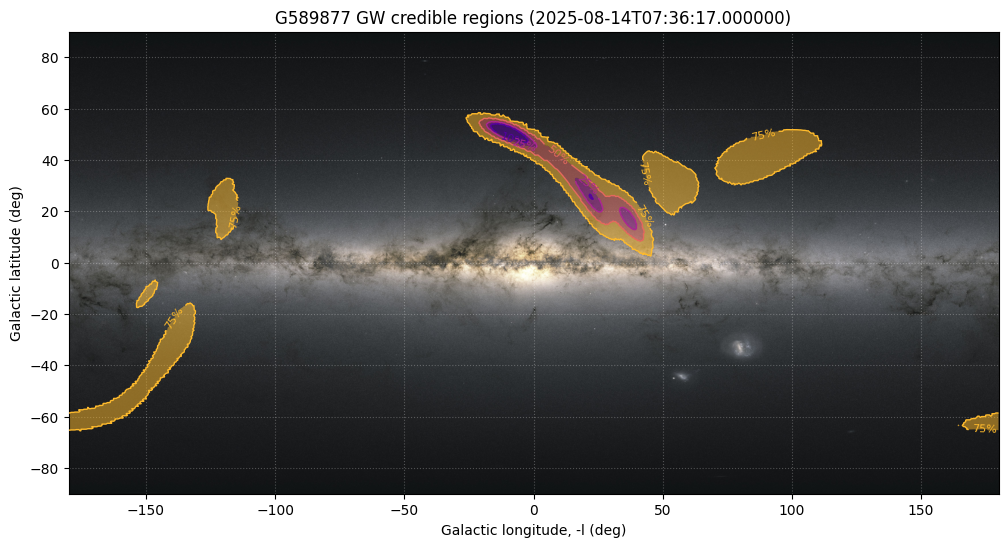

In [3]:
show_contours_from_gw(input_file, levels=([10, 25, 50, 75]))

## **Manually downloading the sky map**

If you prefer to download the sky map manually, you can do so from from either directly from the GaceDB event page (e.g. https://gracedb.ligo.org/) or, alternatively, from the LIGO DCC (https://dcc.ligo.org/LIGO-P1900143/public). Once downloaded, you can specify the path to the file in the `gw_bayestar_file` variable below.

In this case, we will download the `LALInference_v2.fits.gz` file from the LIGO DCC, which contains the sky map for the landmark event [GW170817](https://dcc.ligo.org/LIGO-G1701985/public).

In [4]:
import os
if not Path("data/LALInference_v2.fits.gz").exists():
    os.system("wget https://dcc.ligo.org/public/0146/G1701985/001/LALInference_v2.fits.gz --directory-prefix=./data")

Here we show contours at the 50, 90, and 99.9 percent credibility levels - note how much smaller even the 99.9% contour is compared to the previous exmaple, which is a consequence of the much better localization of GW170817 (see [Abbott et al. 2017](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.119.161101) for details on the event and its localization).

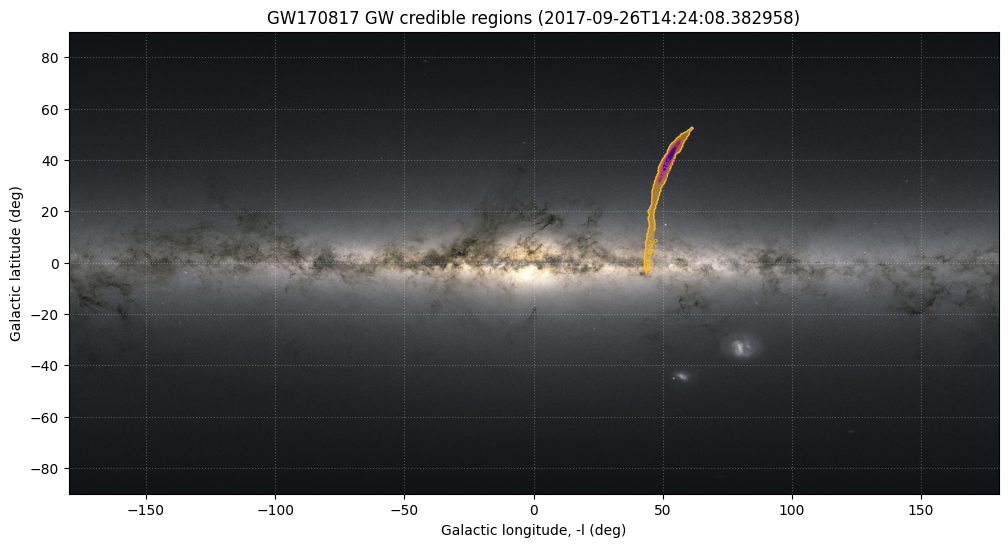

In [5]:
event_name = 'GW170817' 
input_file = './data/LALInference_v2.fits.gz' 

show_contours_from_gw(input_file, levels=([50, 90, 99.9]))

# **3. Convert contours into archive-query polygons**

Archive queries use polygon strings rather than raw contour arrays. We therefore down-sample each contour to a manageable number of vertices and convert it into a format that both the Science Portal and TAP can use. 

To do so, we first pass the input file to the `contours_from_gw` function, which extracts the contours at the specified credible level. We then use the `contours_to_polygons` function to convert these into a list of polygon objects, which can be used to build archive query strings.

**Note:** This example assumes that there is only one contour present in the localization region (e.g. if the localization is poor and then detached contrours can be present). If there are multiple, you can loop over the `polygons` list and repeat the steps below for each of them.

In [6]:
credible_level = 8 # percent credibility contour
contours = contours_from_gw(input_file, credible_level=credible_level)
polygons = contours_to_polygons(contours, max_vertices=30)
polygon = polygons[0] # we assume there is only one contour present in the localization region

## **Optional: Build the equivalent Science Portal queries**

One way to inspect the localization region is through the Archive Science Portal. The helper below constructs one URL per polygon (if multiple polygons are present). You can click on these to open the Science Portal with the polygon constraint already filled in and results 

In [7]:
science_portal_url = build_science_portal_urls_from_polygons(polygons)
science_portal_url

['https://archive.eso.org/scienceportal/home?poly=195.90820,-20.90202,196.04004,-21.02186,196.17187,-21.22180,196.30371,-21.42201,196.52344,-21.62250,196.74316,-21.82327,196.87500,-22.02432,197.00684,-22.22565,197.13867,-22.42728,197.27051,-22.62920,197.40234,-22.83141,197.44629,-23.03393,197.49023,-23.23675,197.53418,-23.43988,197.31445,-23.31796,197.09473,-23.11502,196.96289,-22.91238,196.83105,-22.71005,196.61133,-22.50801,196.56738,-22.30627,196.43555,-22.10482,196.39160,-21.90365,196.25977,-21.70278,196.12793,-21.50218,196.08398,-21.30185,196.04004,-21.10180,195.90820,-20.90202&sort=-obs_date']

# **4. Query the archive programmatically**

For the programmatic query we work directly against `ivoa.ObsCore`. Here we can be directly input the polygon string into the ADQL query for use in the `eso.query_tap` method. 

As the polygon is still relatively large on the sky (despite the event being well localized), here we also add a constraint on the instrument name to focus on X-shooter data. 

In [8]:
query = """
        SELECT *
        FROM ivoa.ObsCore
        WHERE INTERSECTS(s_region, POLYGON('J2000', {}))=1
        AND instrument_name='XSHOOTER'
        """.format(polygon)

eso = Eso()
result_from_query = eso.query_tap(query)
result_from_query[:3]

abmaglim,access_estsize,access_format,access_url,bib_reference,calib_level,dataproduct_subtype,dataproduct_type,dp_id,em_max,em_min,em_res_power,em_xel,facility_name,filter,gal_lat,gal_lon,instrument_name,is_solar,last_mod_date,multi_ob,n_obs,o_calib_status,o_ucd,obs_collection,obs_creator_did,obs_creator_name,obs_id,obs_publisher_did,obs_release_date,obs_title,obstech,p3orig,pol_states,pol_xel,preview_html,proposal_id,publication_date,release_description,s_dec,s_fov,s_pixel_scale,s_ra,s_region,s_resolution,s_xel1,s_xel2,snr,strehl,t_exptime,t_max,t_min,t_resolution,t_xel,target_name
mag,kbyte,,,,,,,,m,m,,,,,deg,deg,,,,,,,,,,,,,,,,,,,,,,,deg,deg,arcsec,deg,,arcsec,,,,,s,d,d,s,,
float64,int64,object,object,object,int32,object,object,object,float64,float64,float64,int64,object,object,float64,float64,object,int16,object,object,int32,object,object,object,object,object,object,object,object,object,object,object,object,int64,object,object,object,object,float64,float64,float64,float64,object,float64,int64,int64,float64,float64,float64,float64,float64,float64,int64,object
--,734,application/x-votable+xml;content=datalink,http://archive.eso.org/datalink/links?ID=ivo://eso.org/ID?ADP.2017-09-22T07:51:05.851,,2,flux-calibrated,spectrum,ADP.2017-09-22T07:51:05.851,5.5598e-07,2.9892000000000003e-07,4112.0,12854,ESO-VLT-U2,,39.296002,308.380289,XSHOOTER,0,2026-02-17T12:20:27.253Z,S,2,absolute,,XSHOOTER,ivo://eso.org/origfile?XS_SFLX_1674072_2017-08-19T23:28:40.740_S1.3x11_1x2_UVB_NOD.fits,"SMARTT, STEPHEN",1674072,ivo://eso.org/ID?ADP.2017-09-22T07:51:05.851,2017-10-16T14:00:00Z,PS16xxx_1674072_2017-08-19T23:28:40.740_S1.3x11_1x2_UVB_NOD,"ECHELLE,SLIT,NODDING",IDP,,--,https://archive.eso.org/dataset/ADP.2017-09-22T07:51:05.851,099.D-0376(A),2017-09-22T07:57:34Z,http://www.eso.org/rm/api/v1/public/releaseDescriptions/70,-23.38129,0.00036083,--,197.45105,POSITION J2000 197.45105 -23.38129,--,--,--,4.2,--,2800.0,57985.01177132,57984.97824929,2896.303392,--,PS16xxx
--,1362,application/x-votable+xml;content=datalink,http://archive.eso.org/datalink/links?ID=ivo://eso.org/ID?ADP.2017-09-22T07:52:27.605,,2,flux-calibrated,spectrum,ADP.2017-09-22T07:52:27.605,2.47896e-06,9.9402e-07,4287.0,24750,ESO-VLT-U2,,39.296044,308.38041,XSHOOTER,0,2026-02-17T12:20:27.253Z,S,10,absolute,,XSHOOTER,ivo://eso.org/origfile?XS_SFLX_1674074_2017-08-21T23:25:41.478_S1.2x11_NIR_NOD.fits,"SMARTT, STEPHEN",1674074,ivo://eso.org/ID?ADP.2017-09-22T07:52:27.605,2017-10-16T14:00:00Z,PS16xxx_1674074_2017-08-21T23:25:41.478_S1.2x11_NIR_NOD,"ECHELLE,SLIT,NODDING",IDP,,--,https://archive.eso.org/dataset/ADP.2017-09-22T07:52:27.605,099.D-0376(A),2017-09-22T07:57:34Z,http://www.eso.org/rm/api/v1/public/releaseDescriptions/70,-23.38124,0.00033305,--,197.451147,POSITION J2000 197.451147 -23.38124,--,--,--,5.2,--,2850.0,57987.0103746,57986.97617451,2954.887776,--,PS16xxx
--,1330,application/x-votable+xml;content=datalink,http://archive.eso.org/datalink/links?ID=ivo://eso.org/ID?ADP.2017-09-22T07:54:12.965,,2,flux-calibrated,spectrum,ADP.2017-09-22T07:54:12.965,1.02e-06,5.336599999999999e-07,8935.0,24318,ESO-VLT-U2,,39.298394,308.375774,XSHOOTER,0,2026-02-17T12:20:27.253Z,S,3,absolute,,XSHOOTER,ivo://eso.org/origfile?XS_SFLX_1687133_2017-08-23T23:34:58.703_S0.9x11_1x2_VIS_NOD.fits,"D'AVANZO, P.",1687133,ivo://eso.org/ID?ADP.2017-09-22T07:54:12.965,2018-08-24T00:45:59.943Z,GRB_1687133_2017-08-23T23:34:58.703_S0.9x11_1x2_VIS_NOD,"ECHELLE,SLIT,NODDING",IDP,,--,https://archive.eso.org/dataset/ADP.2017-09-22T07:54:12.965,099.D-0622(C),2017-09-22T07:57:34Z,http://www.eso.org/rm/api/v1/public/releaseDescriptions/70,-23.37923,0.00025,--,197.44702,POSITION J2000 197.44702 -23.37923,--,--,--,4.1,--,3600.0,57989.02654819,57988.98262387,3795.061248,--,GRB


# **5. Download returned products**

Once the archive query has returned a table, the download step is the same as in the other notebooks: pick a `dp_id` and pass it to `retrieve_data()`.

In [9]:
data_dir = "data/"
data_files = eso.retrieve_data(result_from_query['dp_id'], destination=data_dir)

2026-06-02 10:43:21,229 INFO Downloading datasets ...
2026-06-02 10:43:21,230 INFO Downloading 64 files ...
2026-06-02 10:43:21,230 INFO Downloading file 1/64 https://dataportal.eso.org/dataPortal/file/ADP.2017-09-22T07:51:05.851 to /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/astroquery_examples_eso/examples/case_studies/data


INFO: Downloading datasets ... [astroquery.eso.core]
INFO: Downloading 64 files ... [astroquery.eso.core]
INFO: Downloading file 1/64 https://dataportal.eso.org/dataPortal/file/ADP.2017-09-22T07:51:05.851 to /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/astroquery_examples_eso/examples/case_studies/data [astroquery.eso.core]


2026-06-02 10:43:21,642 INFO Found cached file /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/astroquery_examples_eso/examples/case_studies/data/ADP.2017-09-22T07:51:05.851.fits
2026-06-02 10:43:21,644 INFO Downloading file 2/64 https://dataportal.eso.org/dataPortal/file/ADP.2017-09-22T07:52:27.605 to /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/astroquery_examples_eso/examples/case_studies/data


INFO: Found cached file /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/astroquery_examples_eso/examples/case_studies/data/ADP.2017-09-22T07:51:05.851.fits [astroquery.eso.core]
INFO: Downloading file 2/64 https://dataportal.eso.org/dataPortal/file/ADP.2017-09-22T07:52:27.605 to /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/astroquery_examples_eso/examples/case_studies/data [astroquery.eso.core]


2026-06-02 10:43:21,918 INFO Found cached file /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/astroquery_examples_eso/examples/case_studies/data/ADP.2017-09-22T07:52:27.605.fits
2026-06-02 10:43:21,919 INFO Downloading file 3/64 https://dataportal.eso.org/dataPortal/file/ADP.2017-09-22T07:54:12.965 to /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/astroquery_examples_eso/examples/case_studies/data


...

INFO: Found cached file /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/astroquery_examples_eso/examples/case_studies/data/ADP.2017-10-16T11:29:40.305.fits [astroquery.eso.core]
INFO: Downloading file 63/64 https://dataportal.eso.org/dataPortal/file/ADP.2017-10-16T11:28:41.267 to /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/astroquery_examples_eso/examples/case_studies/data [astroquery.eso.core]


2026-06-02 10:43:40,060 INFO Found cached file /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/astroquery_examples_eso/examples/case_studies/data/ADP.2017-10-16T11:28:41.267.fits
2026-06-02 10:43:40,062 INFO Downloading file 64/64 https://dataportal.eso.org/dataPortal/file/ADP.2017-10-16T11:29:40.345 to /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/astroquery_examples_eso/examples/case_studies/data


INFO: Found cached file /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/astroquery_examples_eso/examples/case_studies/data/ADP.2017-10-16T11:28:41.267.fits [astroquery.eso.core]
INFO: Downloading file 64/64 https://dataportal.eso.org/dataPortal/file/ADP.2017-10-16T11:29:40.345 to /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/astroquery_examples_eso/examples/case_studies/data [astroquery.eso.core]


2026-06-02 10:43:40,341 INFO Found cached file /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/astroquery_examples_eso/examples/case_studies/data/ADP.2017-10-16T11:29:40.345.fits
2026-06-02 10:43:40,343 INFO Done!


INFO: Found cached file /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/astroquery_examples_eso/examples/case_studies/data/ADP.2017-10-16T11:29:40.345.fits [astroquery.eso.core]
INFO: Done! [astroquery.eso.core]


# **6. Visualise Results for GW170817**

In this section we visualise the X-shooter observations obtained with ESO’s Very Large Telescope returned within the gravitational-wave localisation region.

Asgain, we consider the landmark event [**GW170817**](https://www.eso.org/public/news/eso1733/), the first gravitational-wave detection with a confirmed electromagnetic counterpart. This event originated from the merger of two neutron stars in the galaxy **NGC 4993**, at a distance of ~130 million light-years.

The detection marked the beginning of *multi-messenger astronomy*, combining gravitational waves (from LIGO/Virgo) with electromagnetic observations across the spectrum. Follow-up campaigns involving ESO facilities — including the VLT, VISTA, and others — identified a rapidly evolving transient known as a **kilonova**, powered by the radioactive decay of heavy elements produced in the merger.

Key observational features of GW170817 include:
- a rapidly fading optical/infrared transient associated with NGC 4993  
- strong spectral evolution from blue to red over a few days  
- evidence for **r-process nucleosynthesis**, producing elements such as gold and platinum  

Below is a reconstruction of https://www.eso.org/public/images/eso1733j/. 

The spectra trace the evolution of the kilonova in the galaxy NGC 4993 over ~20 days following the detection on 17 August 2017.

**Credit:** ESO/E. Pian et al./S. Smartt & ePESSTO

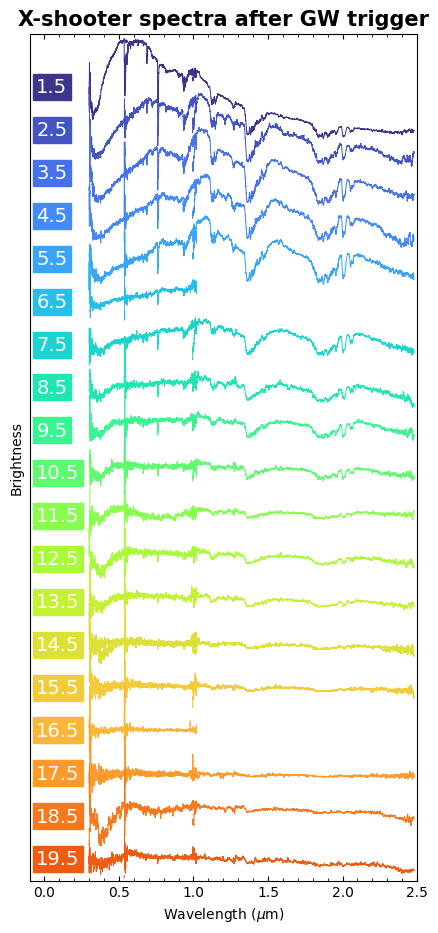

In [10]:
from helpers.gw import show_xshooter_spectra_from_gw

show_xshooter_spectra_from_gw(
    data_files,
    event_file = "data/LALInference_v2.fits.gz",
    save_figure = "figures/GW170817_xshooter_montage.png",
)

---

## **Additional Resources**

The following key papers present the detailed observational and theoretical interpretation of the event:

- **Pian et al. (2017)** — [*Spectroscopic identification of r-process nucleosynthesis in a double neutron star merger*](https://www.eso.org/public/archives/releases/sciencepapers/eso1733/eso1733a.pdf)

- **Tanvir et al. (2017)** — [*The emergence of a lanthanide-rich kilonova following the merger of two neutron stars*](https://www.eso.org/public/archives/releases/sciencepapers/eso1733/eso1733b.pdf)

- **Smartt et al. (2017)** — [*The electromagnetic counterpart to a gravitational wave source unveils a kilonova*](https://www.eso.org/public/archives/releases/sciencepapers/eso1733/eso1733c.pdf)

- **Covino et al. (2017)** — [*The unpolarized macronova associated with the gravitational wave event GW170817*](https://www.eso.org/public/archives/releases/sciencepapers/eso1733/eso1733d.pdf)

- **Hjorth et al. (2017)** — [*The distance to NGC 4993 — the host galaxy of the gravitational wave event GW170817*](https://www.eso.org/public/archives/releases/sciencepapers/eso1733/eso1733e.pdf)

- **Levan et al. (2017)** — [*The environment of the binary neutron star merger GW170817*](https://www.eso.org/public/archives/releases/sciencepapers/eso1733/eso1733f.pdf)

<hr style="border:2px solid #0281c9"> </hr>